In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

COLOR_MAP = {
    "drive": "orange",
    "readout": "tab:blue"
}

def pulse_envelope(ev, t, t_start):
    amp = ev["amplitude"]
    dur = ev["duration"]
    shape = ev.get("shape", "rectangular").lower()

    t_rel = t - t_start

    if shape == "rectangular":
        env = ((t_rel >= 0) & (t_rel <= dur)).astype(float)

    elif shape == "gaussian":
        tc = dur / 2
        sigma = dur / 6
        env = np.exp(-0.5 * ((t_rel - tc) / sigma) ** 2)
        env *= ((t_rel >= 0) & (t_rel <= dur))

    else:
        raise ValueError(f"Unsupported shape: {shape}")

    return amp * env


def plot_pulse_sequence(seq_dict, dt=0.001):
    sequence = seq_dict["sequence"]

    scheduled = []
    t_global = 0.0
    t_max = 0.0

    for ev in sequence:
        t_start = t_global + ev["start_delay"]
        t_end = t_start + ev["duration"]

        scheduled.append((ev, t_start, t_end))

        t_global = t_start
        t_max = max(t_max, t_end)

    t = np.arange(0, t_max + dt, dt)

    waveforms = defaultdict(lambda: np.zeros_like(t))

    for ev, t_start, _ in scheduled:
        waveforms[ev["dac"]] += pulse_envelope(ev, t, t_start)

    dacs = sorted(waveforms.keys())

    fig, axes = plt.subplots(
        len(dacs),
        1,
        sharex=True,
        figsize=(12, 2.8 * len(dacs))
    )

    if len(dacs) == 1:
        axes = [axes]

    for ax, dac in zip(axes, dacs):
        ax.plot(t, waveforms[dac], color="black", linewidth=1)

        for ev, t_start, t_end in scheduled:
            if ev["dac"] != dac:
                continue

            env = pulse_envelope(ev, t, t_start)
            mask = env > 0

            ev_type = ev.get("type", "unknown").lower()
            color = COLOR_MAP.get(ev_type, "gray")

            ax.fill_between(
                t[mask],
                0,
                env[mask],
                color=color,
                alpha=0.4,
                linewidth=0
            )

            ax.text(
                t_start + ev["duration"] / 2,
                1.05 * ev["amplitude"],
                ev_type,
                ha="center",
                va="bottom",
                fontsize=9
            )

        ax.set_ylabel(f"DAC {dac}")
        ax.grid(True, alpha=0.3)

    # xlim leggermente negativo per vedere il rise iniziale
    t_margin = 0.05 * t_max
    axes[-1].set_xlim(-t_margin, t_max)

    axes[-1].set_xlabel("Global time")

    plt.tight_layout()
    plt.show()


In [ ]:
my_dict = {
    'operation_code': 1, 
    'cfg': {'relaxation_time': 250.00000000000003, 'ro_time_of_flight': 200, 'reps': 1000, 'soft_avgs': 1, 'average': True}, 
    'sequence': [
        {'type': 'drive', 'frequency': 4606.528, 'start_delay': 0.0, 'duration': 0.02, 'adc': 0, 'dac': 6, 'amplitude': 0.05, 'relative_phase': 0.0, 'name': '2177574b-aeee-493e-a3d7-1770f33462f4', 'shape': 'rectangular'}, 
        {'type': 'drive', 'frequency': 4606.528, 'start_delay': 0.04, 'duration': 0.025597500000000002, 'adc': 0, 'dac': 2, 'amplitude': 0.1, 'relative_phase': 0.0, 'name': 'a181a6f9-236c-45c9-a5bc-d3cac117cc5c', 'shape': 'rectangular'}, 
        {'type': 'readout', 'frequency': 7398.656187, 'start_delay': 0.0255975, 'duration': 0.0500000000000004, 'adc': 0, 'dac': 0, 'amplitude': 0.01, 'relative_phase': 0.0, 'name': '0c69ef2f-ec09-448e-b9de-86ad01a34ad5', 'shape': 'rectangular'}
    ], 'qubits': [], 'sweepers': []}

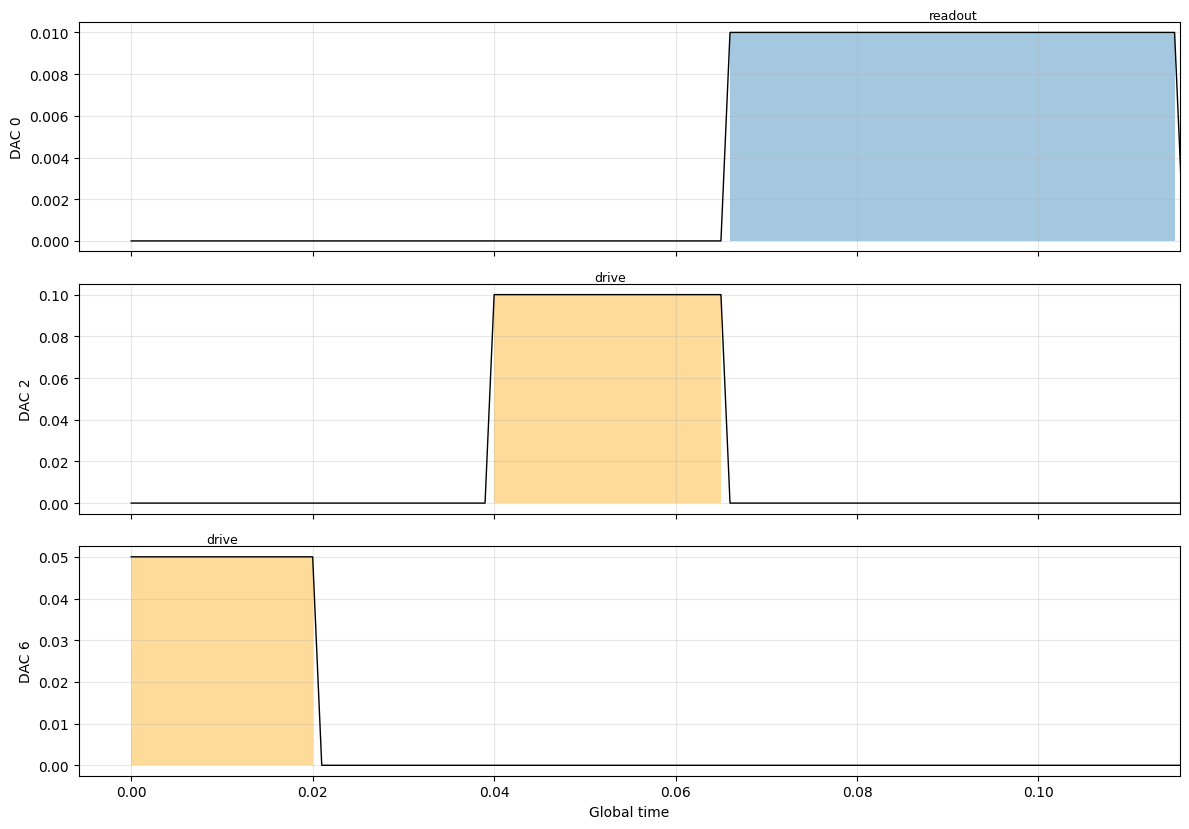

In [ ]:
plot_pulse_sequence(my_dict)